# **MOUNT DRIVE DAN EXPLORATORY DATA ANALYSIS**

Mounted at /content/drive
=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9579 entries, 0 to 9578
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   No         9579 non-null   int64 
 1   Pembelian  9579 non-null   object
 2   Kategori   9579 non-null   object
 3   Tanggal    9579 non-null   object
 4   Jumlah     9579 non-null   int64 
 5   Total      9579 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 449.1+ KB

=== 5 DATA TERATAS ===


,No,Pembelian,Kategori,Tanggal,Jumlah,Total
0,1,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 11:15:00,13,325000
1,2,TIKET MANCANEGARA,Mancanegara,05-05-2025 10:28:00,1,20000
2,3,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 10:00:00,1,25000
3,4,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 09:57:00,7,175000
4,5,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,04-05-2025 11:21:00,4,100000



Jumlah baris : 9579
Jumlah kolom: 6

=== MISSING VALUES ===
No           0
Pembelian    0
Kategori     0
Tanggal      0
Jumlah       0
Total        0
dtype: int64

=== STATISTIK DESKRIPTIF ===


,No,Jumlah,Total
count,9579.000000,9579.000000,9.579000e+03
mean,4790.000000,7.677419,1.556783e+05
std,2765.363448,20.015100,3.900012e+05
min,1.000000,1.000000,1.000000e+04
25%,2395.500000,2.000000,4.000000e+04
50%,4790.000000,3.000000,6.000000e+04
75%,7184.500000,6.000000,1.200000e+05
max,9579.000000,470.000000,9.400000e+06


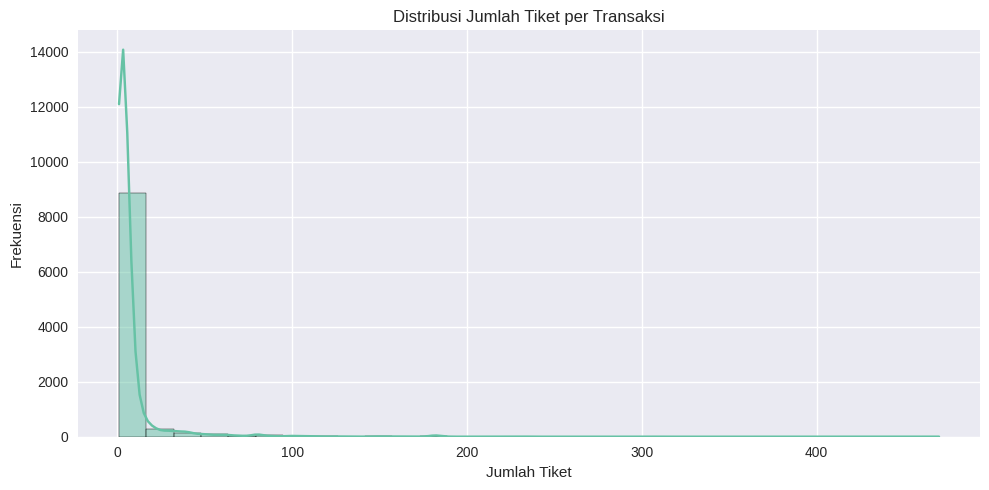

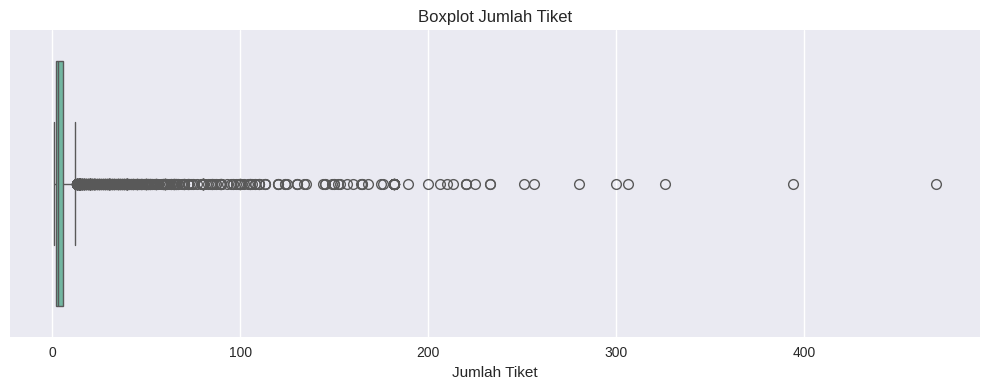

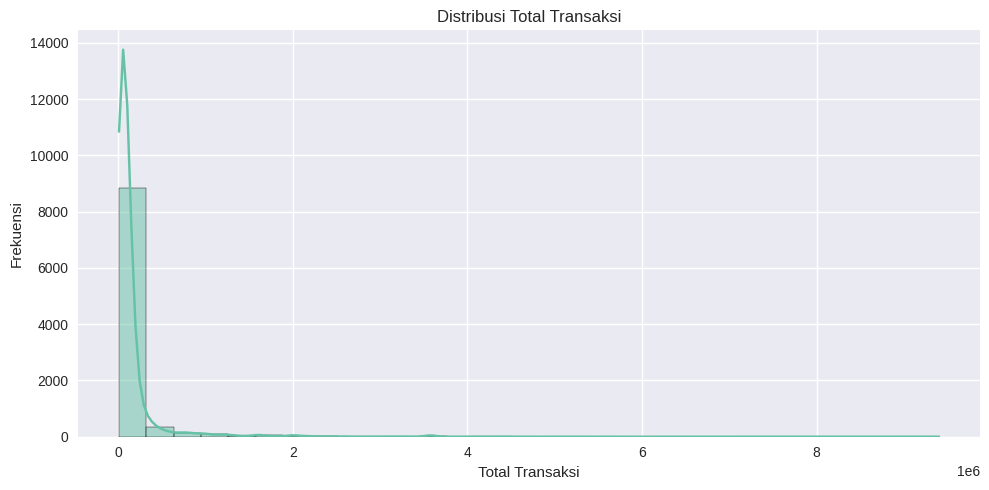

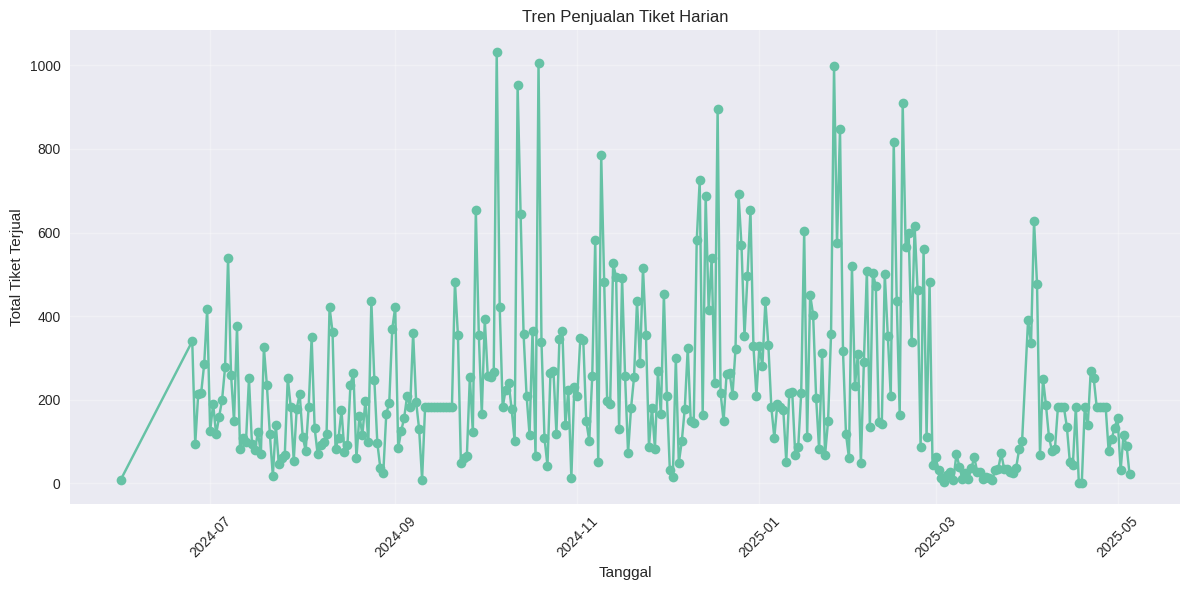

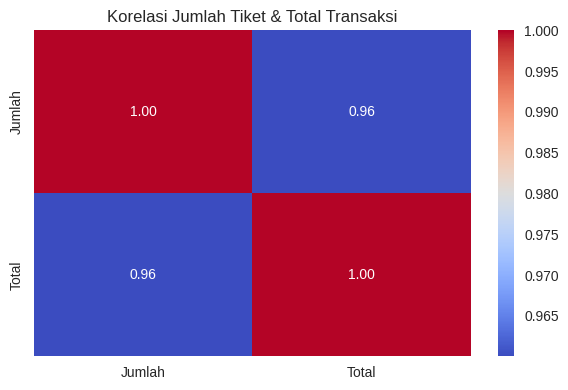


=== INSIGHT EDA ===
Skewness jumlah tiket : 8.54
75% transaksi membeli ≤ 6 tiket


In [ ]:
#setup dan mount drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive
drive.mount('/content/drive')

#konfigurasi path dan visualisasi
file_path = '/content/drive/MyDrive/Clustering_TA/penjualan_tiket_raw.xlsx'

if not os.path.exists(file_path):
    raise FileNotFoundError(
        "File tidak ditemukan"
    )

plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

#load dataset dan cek data awal
df = pd.read_excel(file_path)

print("=== INFORMASI DATASET ===")
df.info()

print("\n=== 5 DATA TERATAS ===")
display(df.head())

print(f"\nJumlah baris : {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

print("\n=== MISSING VALUES ===")
print(df.isna().sum())

print("\n=== STATISTIK DESKRIPTIF ===")
display(df.describe())

#analisis data
#distribusi jumlah tiket
plt.figure(figsize=(10, 5))
sns.histplot(df['Jumlah'], bins=30, kde=True)
plt.title('Distribusi Jumlah Tiket per Transaksi')
plt.xlabel('Jumlah Tiket')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

#boxplot jumlah tiket (deteksi outlier)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Jumlah'])
plt.title('Boxplot Jumlah Tiket')
plt.xlabel('Jumlah Tiket')
plt.tight_layout()
plt.show()

#distribusi total transaksi
plt.figure(figsize=(10, 5))
sns.histplot(df['Total'], bins=30, kde=True)
plt.title('Distribusi Total Transaksi')
plt.xlabel('Total Transaksi')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

#analisis berdasarkan waktu
df['Tanggal'] = pd.to_datetime(
    df['Tanggal'],
    dayfirst=True,
    errors='coerce'
)

daily_sales = (
    df
    .groupby(df['Tanggal'].dt.date)['Jumlah']
    .sum()
)

plt.figure(figsize=(12, 6))
daily_sales.plot(marker='o')
plt.title('Tren Penjualan Tiket Harian')
plt.xlabel('Tanggal')
plt.ylabel('Total Tiket Terjual')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#analisis hubungan antar variabel
numeric_df = df[['Jumlah', 'Total']].dropna()

plt.figure(figsize=(6, 4))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Korelasi Jumlah Tiket & Total Transaksi')
plt.tight_layout()
plt.show()

#insight statistik dan interpretasi data
skewness_jumlah = df['Jumlah'].skew()
q75 = df['Jumlah'].quantile(0.75)

print("\n=== INSIGHT EDA ===")
print(f"Skewness jumlah tiket : {skewness_jumlah:.2f}")
print(f"75% transaksi membeli ≤ {int(q75)} tiket")



# **PREPROCESSING DAN FEATURE ENGINEERING**

In [ ]:
#import dan setup
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/Clustering_TA")
RAW_PATH = BASE_DIR / "penjualan_tiket_raw.xlsx"
PROCESSED_PATH = BASE_DIR / "penjualan_tiket_clean.csv"

print("RAW_PATH      :", RAW_PATH)
print("PROCESSED_PATH:", PROCESSED_PATH)

if not RAW_PATH.exists():
    raise FileNotFoundError("File tidak ditemukan")

#load data
df = pd.read_excel(RAW_PATH)

print("\n=== DATA AWAL ===")
display(df.head())

#preprocessing
#standarisasi nama kolom
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

#konversi kolom tanggal
df['tanggal'] = pd.to_datetime(
    df['tanggal'],
    dayfirst=True,
    errors='coerce'
)

#memastikan kolom numerik
df['jumlah'] = pd.to_numeric(df['jumlah'], errors='coerce')
df['total'] = pd.to_numeric(df['total'], errors='coerce')

#cek missing value setelah konversi
print("\n=== MISSING VALUES SETELAH KONVERSI ===")
print(df.isnull().sum())

#drop data tidak falid
df = df.dropna().reset_index(drop=True)

#feature engineering
#fitur waktu
df['tahun'] = df['tanggal'].dt.year
df['bulan'] = df['tanggal'].dt.month
df['nama_bulan'] = df['tanggal'].dt.month_name()
df['hari'] = df['tanggal'].dt.day
df['hari_dalam_minggu'] = df['tanggal'].dt.day_name()
df['jam'] = df['tanggal'].dt.hour

#weekend vs weekdays
df['is_weekend'] = df['hari_dalam_minggu'].isin(
    ['Saturday', 'Sunday']
).astype(int)

#harga tiket, menghindari harga 0
df['harga_per_tiket'] = np.where(
    df['jumlah'] > 0,
    df['total'] / df['jumlah'],
    np.nan
)

#label volume penjualan
df['volume_penjualan'] = pd.cut(
    df['jumlah'],
    bins=[0, 2, 5, 10, 50, np.inf],
    labels=[
        'Sangat Rendah',
        'Rendah',
        'Sedang',
        'Tinggi',
        'Sangat Tinggi'
    ]
)

#validasi data akhir
print("\n=== DATA SETELAH PREPROCESSING ===")
display(df.head())
print("\n=== INFO DATA ===")
df.info()

#simpan data setelah preprocessing
df.to_csv(PROCESSED_PATH, index=False)
print(f"\n Data disimpan di:\n{PROCESSED_PATH}")


RAW_PATH      : /content/drive/MyDrive/Clustering_TA/penjualan_tiket_raw.xlsx
PROCESSED_PATH: /content/drive/MyDrive/Clustering_TA/penjualan_tiket_clean.csv

=== DATA AWAL ===


,No,Pembelian,Kategori,Tanggal,Jumlah,Total
0,1,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 11:15:00,13,325000
1,2,TIKET MANCANEGARA,Mancanegara,05-05-2025 10:28:00,1,20000
2,3,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 10:00:00,1,25000
3,4,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 09:57:00,7,175000
4,5,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,04-05-2025 11:21:00,4,100000



=== MISSING VALUES SETELAH KONVERSI ===
no           0
pembelian    0
kategori     0
tanggal      0
jumlah       0
total        0
dtype: int64

=== DATA SETELAH PREPROCESSING ===


,no,pembelian,kategori,tanggal,jumlah,total,tahun,bulan,nama_bulan,hari,hari_dalam_minggu,jam,is_weekend,harga_per_tiket,volume_penjualan
0,1,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,2025-05-05 11:15:00,13,325000,2025,5,May,5,Monday,11,0,25000.0,Tinggi
1,2,TIKET MANCANEGARA,Mancanegara,2025-05-05 10:28:00,1,20000,2025,5,May,5,Monday,10,0,20000.0,Sangat Rendah
2,3,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,2025-05-05 10:00:00,1,25000,2025,5,May,5,Monday,10,0,25000.0,Sangat Rendah
3,4,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,2025-05-05 09:57:00,7,175000,2025,5,May,5,Monday,9,0,25000.0,Sedang
4,5,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,2025-05-04 11:21:00,4,100000,2025,5,May,4,Sunday,11,1,25000.0,Rendah



=== INFO DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9579 entries, 0 to 9578
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   no                 9579 non-null   int64         
 1   pembelian          9579 non-null   object        
 2   kategori           9579 non-null   object        
 3   tanggal            9579 non-null   datetime64[ns]
 4   jumlah             9579 non-null   int64         
 5   total              9579 non-null   int64         
 6   tahun              9579 non-null   int32         
 7   bulan              9579 non-null   int32         
 8   nama_bulan         9579 non-null   object        
 9   hari               9579 non-null   int32         
 10  hari_dalam_minggu  9579 non-null   object        
 11  jam                9579 non-null   int32         
 12  is_weekend         9579 non-null   int64         
 13  harga_per_tiket    9579 non-null   float64  

# **DBSCAN CLUSTERING + HPO**

DATA_PATH : /content/drive/MyDrive/Clustering_TA/penjualan_tiket_clean.csv

=== INFO DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9579 entries, 0 to 9578
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   no                 9579 non-null   int64  
 1   pembelian          9579 non-null   object 
 2   kategori           9579 non-null   object 
 3   tanggal            9579 non-null   object 
 4   jumlah             9579 non-null   int64  
 5   total              9579 non-null   int64  
 6   tahun              9579 non-null   int64  
 7   bulan              9579 non-null   int64  
 8   nama_bulan         9579 non-null   object 
 9   hari               9579 non-null   int64  
 10  hari_dalam_minggu  9579 non-null   object 
 11  jam                9579 non-null   int64  
 12  is_weekend         9579 non-null   int64  
 13  harga_per_tiket    9579 non-null   float64
 14  volume_penjualan   9579 no

,jumlah,total,harga_per_tiket,is_weekend,jam
0,13,325000,25000.0,0,11
1,1,20000,20000.0,0,10
2,1,25000,25000.0,0,10
3,7,175000,25000.0,0,9
4,4,100000,25000.0,1,11



Shape Data : (9579, 5)


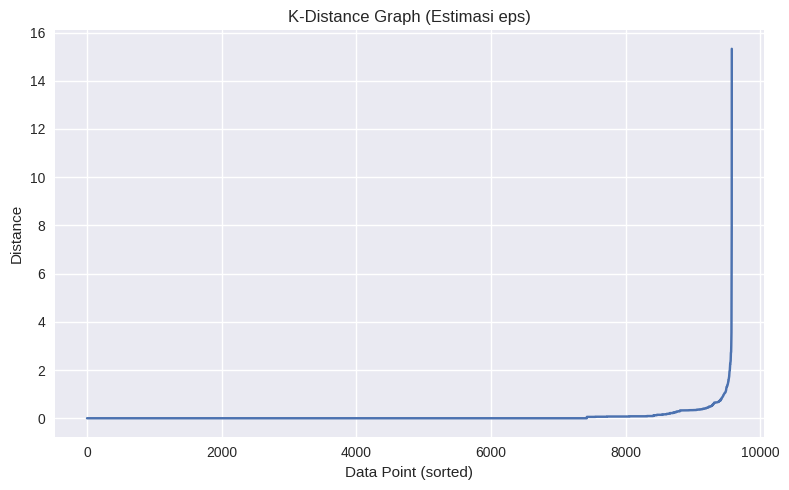


=== HYPERPARAMETER OPTIMIZATION DBSCAN ===
eps=0.3 | min_samples=3 | cluster=197 | noise=4.62% | silhouette=0.5044
eps=0.3 | min_samples=5 | cluster=143 | noise=6.91% | silhouette=0.5115
eps=0.3 | min_samples=7 | cluster=125 | noise=8.25% | silhouette=0.5176
eps=0.3 | min_samples=10 | cluster=118 | noise=9.28% | silhouette=0.5294
eps=0.4 | min_samples=3 | cluster=44 | noise=1.96% | silhouette=0.1674
eps=0.4 | min_samples=5 | cluster=29 | noise=3.03% | silhouette=0.1991
eps=0.4 | min_samples=7 | cluster=24 | noise=3.98% | silhouette=0.2085
eps=0.4 | min_samples=10 | cluster=14 | noise=5.69% | silhouette=0.2048
eps=0.5 | min_samples=3 | cluster=34 | noise=1.60% | silhouette=0.1648
eps=0.5 | min_samples=5 | cluster=24 | noise=2.32% | silhouette=0.1842
eps=0.5 | min_samples=7 | cluster=18 | noise=3.26% | silhouette=0.1969
eps=0.5 | min_samples=10 | cluster=17 | noise=4.44% | silhouette=0.1984
eps=0.6 | min_samples=3 | cluster=33 | noise=1.26% | silhouette=0.1600
eps=0.6 | min_samples=5 | 

,eps,min_samples,n_clusters,noise_count,noise_percentage,silhouette_score,davies_bouldin_score,calinski_harabasz_score
3,0.3,10,118,889,9.280718,0.529405,0.830666,5067.831576
2,0.3,7,125,790,8.247207,0.517641,0.830270,4355.589056
1,0.3,5,143,662,6.910951,0.511506,0.794963,3817.714957
0,0.3,3,197,443,4.624700,0.504403,0.714289,2800.683523
25,0.9,5,4,100,1.043950,0.335222,0.851174,1700.138573
30,1.0,7,4,97,1.012632,0.335127,0.850262,1708.980086
35,1.1,10,3,104,1.085708,0.334681,0.967238,2312.586159
34,1.1,7,4,88,0.918676,0.334287,0.852444,1691.914033
29,1.0,5,4,88,0.918676,0.334182,0.853040,1685.258478
33,1.1,5,4,72,0.751644,0.332812,0.856722,1658.860637



=== PARAMETER TERBAIK ===
eps                  : 0.30
min_samples          : 10
Jumlah Cluster       : 118
Noise Percentage     : 9.28%
Silhouette Score     : 0.5294
Davies Bouldin       : 0.8307
Calinski Harabasz    : 5067.83

=== DISTRIBUSI CLUSTER ===
cluster_dbscan
-1      889
 2      255
 0      201
 3      199
 26     198
       ... 
 113     11
 101     10
 99      10
 98      10
 103     10
Name: count, Length: 119, dtype: int64

Jumlah Noise/Outlier : 889

=== RATA-RATA FITUR PER CLUSTER ===


,jumlah,total,harga_per_tiket,is_weekend,jam
cluster_dbscan,,,,,
0,4.42,110572.14,25000.0,0.0,11.0
1,3.77,75460.12,20000.0,0.0,10.0
2,3.93,98333.33,25000.0,0.0,10.0
3,4.35,108793.97,25000.0,0.0,9.0
4,4.31,107868.02,25000.0,1.0,11.0
...,...,...,...,...,...
113,1.91,19090.91,10000.0,1.0,18.0
114,3.96,99107.14,25000.0,1.0,17.0
115,2.55,63636.36,25000.0,1.0,22.0


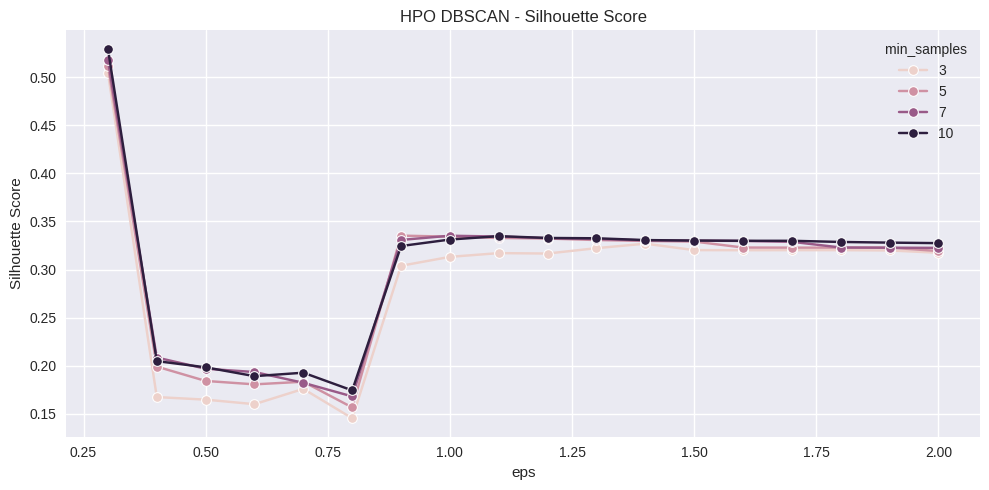

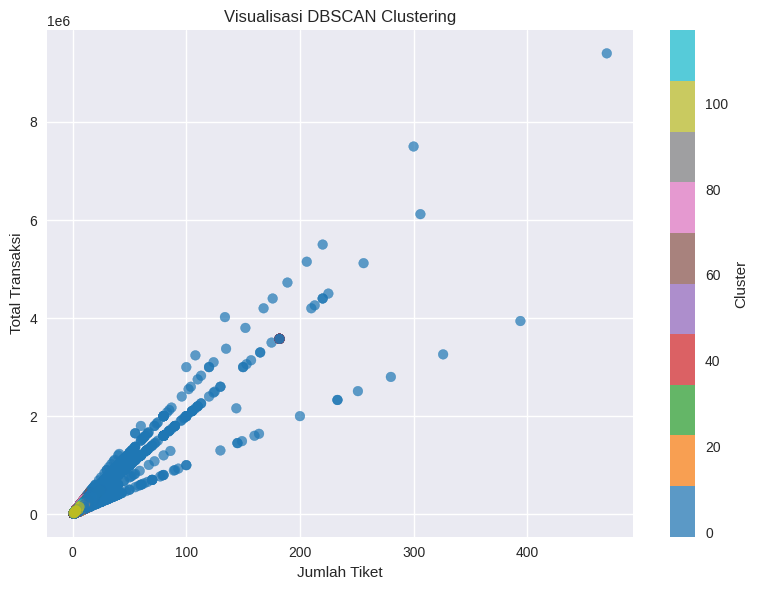


=== INFORMASI CLUSTER DBSCAN ===
Jumlah Cluster Terbentuk : 118
Jumlah Noise/Outlier     : 889

Hasil clustering disimpan di:
/content/drive/MyDrive/Clustering_TA/penjualan_tiket_dbscan.csv

Hasil HPO disimpan di:
/content/drive/MyDrive/Clustering_TA/hasil_hpo_dbscan.csv

Total waktu eksekusi: 188.68 detik


In [ ]:
# ======================================================
# IMPORT DAN SETUP
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from pathlib import Path

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

plt.style.use("seaborn-v0_8")

# ======================================================
# PATH
# ======================================================

BASE_DIR = Path("/content/drive/MyDrive/Clustering_TA")

DATA_PATH = BASE_DIR / "penjualan_tiket_clean.csv"

OUTPUT_PATH = BASE_DIR / "penjualan_tiket_dbscan.csv"

HPO_RESULT_PATH = BASE_DIR / "hasil_hpo_dbscan.csv"

print("DATA_PATH :", DATA_PATH)

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_csv(DATA_PATH)

print("\n=== INFO DATA ===")

df.info()

# ======================================================
# SELEKSI FITUR
# ======================================================

features = [
    "jumlah",
    "total",
    "harga_per_tiket",
    "is_weekend",
    "jam"
]

X = df[features].copy()

# ======================================================
# HANDLE MISSING VALUE
# ======================================================

X = (
    X
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

df = df.loc[X.index].reset_index(drop=True)

X = X.reset_index(drop=True)

print("\n=== SAMPLE DATA ===")

display(X.head())

# ======================================================
# SCALING DATA
# ======================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nShape Data :", X_scaled.shape)

# ======================================================
# K-DISTANCE GRAPH
# ======================================================

neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = (
    neighbors_fit.kneighbors(X_scaled)
)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 5))

plt.plot(distances)

plt.title(
    "K-Distance Graph "
    "(Estimasi eps)"
)

plt.xlabel("Data Point (sorted)")

plt.ylabel("Distance")

plt.tight_layout()

plt.show()

# ======================================================
# HPO DBSCAN
# ======================================================

print("\n=== HYPERPARAMETER OPTIMIZATION DBSCAN ===")

start_time = time.time()

# ======================================================
# PARAMETER HPO
# ======================================================

eps_values = np.arange(
    0.3,
    2.1,
    0.1
)

min_samples_values = [
    3,
    5,
    7,
    10
]

# ======================================================
# MENYIMPAN HASIL
# ======================================================

results = []

# ======================================================
# LOOPING HPO
# ======================================================

for eps in eps_values:

    for min_samples in min_samples_values:

        try:

            # ======================================================
            # TRAIN DBSCAN
            # ======================================================

            dbscan = DBSCAN(
                eps=eps,
                min_samples=min_samples
            )

            labels = dbscan.fit_predict(
                X_scaled
            )

            # ======================================================
            # HITUNG JUMLAH CLUSTER
            # ======================================================

            unique_labels = set(labels)

            n_clusters = len(unique_labels)

            if -1 in unique_labels:
                n_clusters -= 1

            # ======================================================
            # HITUNG NOISE
            # ======================================================

            noise_count = (
                labels == -1
            ).sum()

            noise_percentage = (
                noise_count / len(labels)
            ) * 100

            # ======================================================
            # SKIP JIKA CLUSTER TIDAK VALID
            # ======================================================

            if n_clusters <= 1:

                print(
                    f"SKIP | eps={eps:.1f} | "
                    f"min_samples={min_samples} | "
                    f"cluster terlalu sedikit"
                )

                continue

            # ======================================================
            # REMOVE NOISE UNTUK EVALUASI
            # ======================================================

            mask = labels != -1

            X_filtered = X_scaled[mask]

            labels_filtered = labels[mask]

            # ======================================================
            # EVALUASI CLUSTER
            # ======================================================

            silhouette = silhouette_score(
                X_filtered,
                labels_filtered
            )

            davies = davies_bouldin_score(
                X_filtered,
                labels_filtered
            )

            calinski = calinski_harabasz_score(
                X_filtered,
                labels_filtered
            )

            # ======================================================
            # SIMPAN HASIL
            # ======================================================

            results.append({
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "noise_count": noise_count,
                "noise_percentage": noise_percentage,
                "silhouette_score": silhouette,
                "davies_bouldin_score": davies,
                "calinski_harabasz_score": calinski
            })

            print(
                f"eps={eps:.1f} | "
                f"min_samples={min_samples} | "
                f"cluster={n_clusters} | "
                f"noise={noise_percentage:.2f}% | "
                f"silhouette={silhouette:.4f}"
            )

        except Exception as e:

            print(
                f"ERROR eps={eps} "
                f"min_samples={min_samples}"
            )

            print(e)

# ======================================================
# HASIL HPO
# ======================================================

hpo_results = pd.DataFrame(results)

print("\nJumlah kombinasi valid :")

print(len(hpo_results))

# ======================================================
# SORT HASIL TERBAIK
# ======================================================

best_results = hpo_results.sort_values(
    by="silhouette_score",
    ascending=False
)

print("\n=== TOP 10 HASIL TERBAIK ===")

display(best_results.head(10))

# ======================================================
# PARAMETER TERBAIK
# ======================================================

best_params = best_results.iloc[0]

print("\n=== PARAMETER TERBAIK ===")

print(f"eps                  : {best_params['eps']:.2f}")

print(f"min_samples          : {int(best_params['min_samples'])}")

print(f"Jumlah Cluster       : {int(best_params['n_clusters'])}")

print(f"Noise Percentage     : {best_params['noise_percentage']:.2f}%")

print(f"Silhouette Score     : {best_params['silhouette_score']:.4f}")

print(f"Davies Bouldin       : {best_params['davies_bouldin_score']:.4f}")

print(f"Calinski Harabasz    : {best_params['calinski_harabasz_score']:.2f}")

# ======================================================
# TRAIN FINAL MODEL
# ======================================================

best_dbscan = DBSCAN(
    eps=float(best_params['eps']),
    min_samples=int(best_params['min_samples'])
)

df["cluster_dbscan"] = (
    best_dbscan.fit_predict(X_scaled)
)

# ======================================================
# HASIL CLUSTER
# ======================================================

print("\n=== DISTRIBUSI CLUSTER ===")

print(
    df["cluster_dbscan"]
    .value_counts()
)

# ======================================================
# JUMLAH NOISE
# ======================================================

noise_count = (
    df["cluster_dbscan"] == -1
).sum()

print(
    f"\nJumlah Noise/Outlier : "
    f"{noise_count}"
)

# ======================================================
# ANALISIS CLUSTER
# ======================================================

cluster_summary = (
    df[df["cluster_dbscan"] != -1]
    .groupby("cluster_dbscan")[features]
    .mean()
    .round(2)
)

print("\n=== RATA-RATA FITUR PER CLUSTER ===")

display(cluster_summary)

# ======================================================
# VISUALISASI HPO
# ======================================================

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hpo_results,
    x='eps',
    y='silhouette_score',
    hue='min_samples',
    marker='o'
)

plt.title(
    'HPO DBSCAN - Silhouette Score'
)

plt.xlabel('eps')

plt.ylabel('Silhouette Score')

plt.tight_layout()

plt.show()

# ======================================================
# VISUALISASI CLUSTER
# ======================================================

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df["jumlah"],
    df["total"],
    c=df["cluster_dbscan"],
    cmap="tab10",
    alpha=0.7
)

plt.title("Visualisasi DBSCAN Clustering")

plt.xlabel("Jumlah Tiket")

plt.ylabel("Total Transaksi")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.tight_layout()

plt.show()

final_labels = df["cluster_dbscan"]

unique_clusters = set(final_labels)

n_final_clusters = len(unique_clusters)

if -1 in unique_clusters:
    n_final_clusters -= 1

print("\n=== INFORMASI CLUSTER DBSCAN ===")

print(f"Jumlah Cluster Terbentuk : {n_final_clusters}")

print(f"Jumlah Noise/Outlier     : {(final_labels == -1).sum()}")

results.append({
    "eps": eps,
    "min_samples": min_samples,
    "n_clusters": n_clusters,
    "noise_count": noise_count,
    "noise_percentage": noise_percentage,
    "silhouette_score": silhouette,
    "davies_bouldin_score": davies,
    "calinski_harabasz_score": calinski
})

# ======================================================
# SIMPAN HASIL
# ======================================================

df.to_csv(
    OUTPUT_PATH,
    index=False
)

hpo_results.to_csv(
    HPO_RESULT_PATH,
    index=False
)

print(
    f"\nHasil clustering disimpan di:\n"
    f"{OUTPUT_PATH}"
)

print(
    f"\nHasil HPO disimpan di:\n"
    f"{HPO_RESULT_PATH}"
)


# ======================================================
# TOTAL WAKTU EKSEKUSI
# ======================================================

end_time = time.time()

execution_time = end_time - start_time

print(
    f"\nTotal waktu eksekusi: "
    f"{execution_time:.2f} detik"
)

# **EVALUASI PERFORMANCE MODEL DBSCAN CLUSTERING**

=== EVALUASI MODEL DBSCAN ===

=== PARAMETER TERBAIK DBSCAN ===
eps         : 0.30
min_samples : 10

Jumlah Cluster : 119
Jumlah Noise   : 889
Persentase Noise : 9.28%
Interpretasi Noise : Noise dalam batas normal

Jumlah data tanpa noise : 8690

Silhouette Score : 0.5294
Interpretasi : Struktur cluster baik

Davies-Bouldin Index : 0.8307
Semakin kecil DBI maka cluster semakin baik

Calinski-Harabasz Index : 5067.83
Semakin besar CHI maka pemisahan cluster semakin baik

=== DISTRIBUSI CLUSTER ===
cluster_dbscan
-1      889
 0      201
 1      163
 2      255
 3      199
       ... 
 113     11
 114     28
 115     11
 116     11
 117     20
Name: count, Length: 119, dtype: int64

=== RATA-RATA FITUR PER CLUSTER ===


,jumlah,total,harga_per_tiket,is_weekend,jam
cluster_dbscan,,,,,
0,4.42,110572.14,25000.0,0.0,11.0
1,3.77,75460.12,20000.0,0.0,10.0
2,3.93,98333.33,25000.0,0.0,10.0
3,4.35,108793.97,25000.0,0.0,9.0
4,4.31,107868.02,25000.0,1.0,11.0
...,...,...,...,...,...
113,1.91,19090.91,10000.0,1.0,18.0
114,3.96,99107.14,25000.0,1.0,17.0
115,2.55,63636.36,25000.0,1.0,22.0


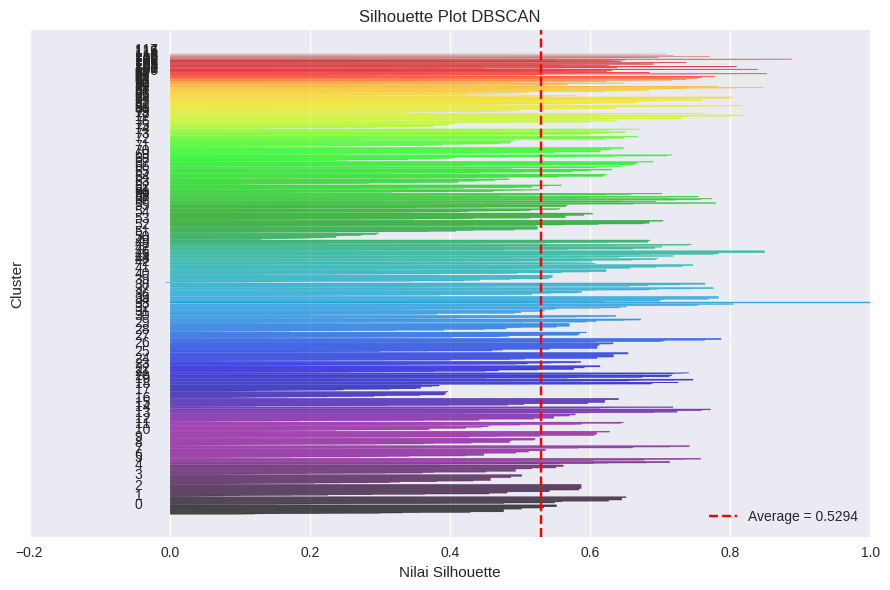

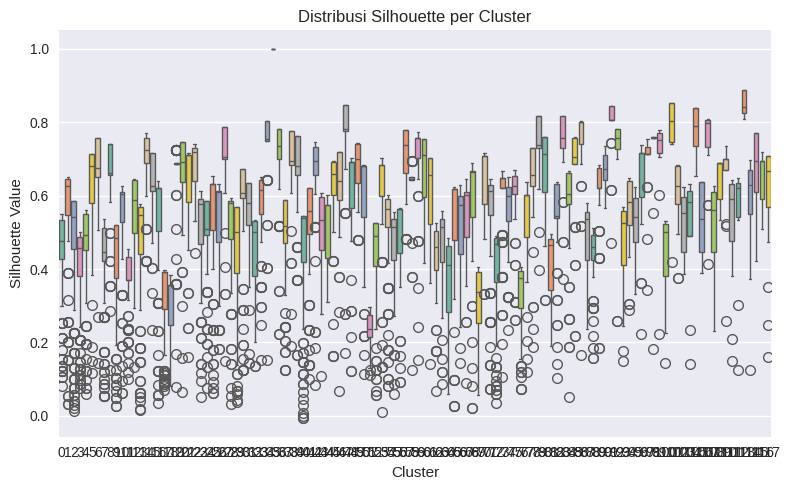


=== RATA-RATA SILHOUETTE PER CLUSTER ===
cluster
0      0.4553
1      0.5592
2      0.4833
3      0.4117
4      0.4653
        ...  
113    0.8486
114    0.5948
115    0.6735
116    0.6447
117    0.5971
Name: silhouette_value, Length: 118, dtype: float64


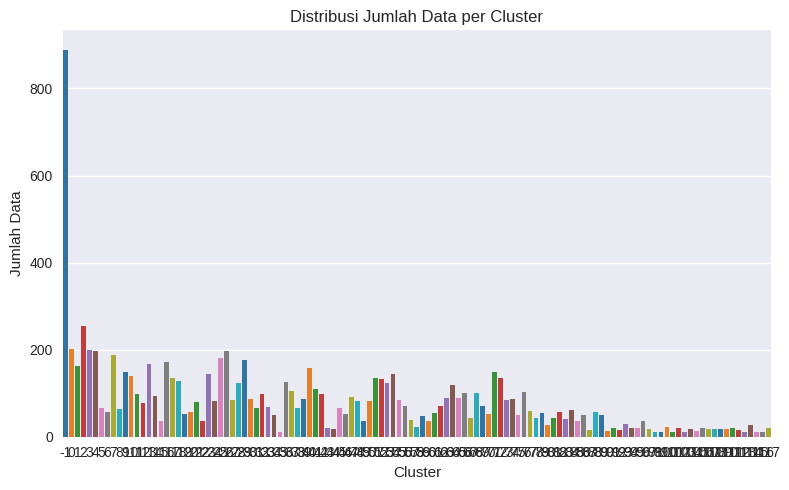


=== EVALUASI DBSCAN SELESAI ===


In [ ]:
# ======================================================
# EVALUASI MODEL DBSCAN
# ======================================================

from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)

import matplotlib.cm as cm

print("=== EVALUASI MODEL DBSCAN ===")

# ======================================================
# LABEL CLUSTER
# ======================================================

labels = df["cluster_dbscan"]

# ======================================================
# INFORMASI PARAMETER TERBAIK
# ======================================================

print("\n=== PARAMETER TERBAIK DBSCAN ===")

print(f"eps         : {best_params['eps']:.2f}")

print(
    f"min_samples : "
    f"{int(best_params['min_samples'])}"
)

# ======================================================
# INFORMASI CLUSTER
# ======================================================

n_clusters = (
    len(set(labels))
    - (1 if -1 in labels else 0)
)

n_noise = list(labels).count(-1)

print(f"\nJumlah Cluster : {n_clusters}")

print(f"Jumlah Noise   : {n_noise}")

noise_percentage = (
    n_noise / len(labels)
) * 100

print(
    f"Persentase Noise : "
    f"{noise_percentage:.2f}%"
)

# ======================================================
# INTERPRETASI NOISE
# ======================================================

if noise_percentage < 5:

    noise_interpretation = (
        "Noise sangat sedikit"
    )

elif noise_percentage < 15:

    noise_interpretation = (
        "Noise dalam batas normal"
    )

elif noise_percentage < 30:

    noise_interpretation = (
        "Noise cukup tinggi"
    )

else:

    noise_interpretation = (
        "Noise terlalu tinggi"
    )

print(
    "Interpretasi Noise :",
    noise_interpretation
)

# ======================================================
# HAPUS NOISE UNTUK EVALUASI
# ======================================================

mask = labels != -1

X_valid = X_scaled[mask]

labels_valid = labels[mask]

print(
    f"\nJumlah data tanpa noise : "
    f"{len(labels_valid)}"
)

# ======================================================
# VALIDASI JUMLAH CLUSTER
# ======================================================

unique_clusters = np.unique(labels_valid)

valid_cluster_count = len(unique_clusters)

# ======================================================
# SILHOUETTE SCORE
# ======================================================

if valid_cluster_count > 1:

    sil_score = silhouette_score(
        X_valid,
        labels_valid
    )

    print(
        f"\nSilhouette Score : "
        f"{sil_score:.4f}"
    )

    # ======================================================
    # INTERPRETASI SILHOUETTE
    # ======================================================

    if sil_score >= 0.71:

        interpretasi = (
            "Struktur cluster sangat kuat"
        )

    elif sil_score >= 0.51:

        interpretasi = (
            "Struktur cluster baik"
        )

    elif sil_score >= 0.26:

        interpretasi = (
            "Struktur cluster cukup"
        )

    else:

        interpretasi = (
            "Struktur cluster lemah"
        )

    print(
        "Interpretasi :",
        interpretasi
    )

else:

    print(
        "\nSilhouette Score "
        "tidak dapat dihitung"
    )

# ======================================================
# DAVIES BOULDIN INDEX
# ======================================================

if valid_cluster_count > 1:

    db_index = davies_bouldin_score(
        X_valid,
        labels_valid
    )

    print(
        f"\nDavies-Bouldin Index : "
        f"{db_index:.4f}"
    )

    print(
        "Semakin kecil DBI "
        "maka cluster semakin baik"
    )

# ======================================================
# CALINSKI HARABASZ INDEX
# ======================================================

if valid_cluster_count > 1:

    ch_index = calinski_harabasz_score(
        X_valid,
        labels_valid
    )

    print(
        f"\nCalinski-Harabasz Index : "
        f"{ch_index:.2f}"
    )

    print(
        "Semakin besar CHI "
        "maka pemisahan cluster semakin baik"
    )

# ======================================================
# DISTRIBUSI CLUSTER
# ======================================================

print("\n=== DISTRIBUSI CLUSTER ===")

cluster_distribution = (
    df["cluster_dbscan"]
    .value_counts()
    .sort_index()
)

print(cluster_distribution)

# ======================================================
# RATA-RATA FITUR CLUSTER
# ======================================================

cluster_summary = (
    df[df["cluster_dbscan"] != -1]
    .groupby("cluster_dbscan")[features]
    .mean()
    .round(2)
)

print("\n=== RATA-RATA FITUR PER CLUSTER ===")

display(cluster_summary)

# ======================================================
# SILHOUETTE SAMPLE
# ======================================================

if valid_cluster_count > 1:

    sample_silhouette_values = (
        silhouette_samples(
            X_valid,
            labels_valid
        )
    )

# ======================================================
# SILHOUETTE PLOT
# ======================================================

if valid_cluster_count > 1:

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    y_lower = 10

    for i in unique_clusters:

        ith_cluster_silhouette_values = (
            sample_silhouette_values[
                labels_valid == i
            ]
        )

        ith_cluster_silhouette_values.sort()

        size_cluster_i = (
            ith_cluster_silhouette_values.shape[0]
        )

        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(
            float(i) / valid_cluster_count
        )

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )

        ax.text(
            -0.05,
            y_lower + 0.5 * size_cluster_i,
            str(i)
        )

        y_lower = y_upper + 10

    ax.axvline(
        x=sil_score,
        color="red",
        linestyle="--",
        label=f"Average = {sil_score:.4f}"
    )

    ax.set_title(
        "Silhouette Plot DBSCAN"
    )

    ax.set_xlabel(
        "Nilai Silhouette"
    )

    ax.set_ylabel(
        "Cluster"
    )

    ax.set_yticks([])

    ax.set_xlim([-0.2, 1])

    ax.legend()

    plt.tight_layout()

    plt.show()

# ======================================================
# DISTRIBUSI SILHOUETTE
# ======================================================

if valid_cluster_count > 1:

    silhouette_df = pd.DataFrame({
        "cluster": labels_valid,
        "silhouette_value":
            sample_silhouette_values
    })

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x="cluster",
        y="silhouette_value",
        hue="cluster",
        data=silhouette_df,
        palette="Set2",
        legend=False
    )

    plt.title(
        "Distribusi Silhouette "
        "per Cluster"
    )

    plt.xlabel("Cluster")

    plt.ylabel(
        "Silhouette Value"
    )

    plt.tight_layout()

    plt.show()

# ======================================================
# RATA-RATA SILHOUETTE
# ======================================================

if valid_cluster_count > 1:

    cluster_silhouette = (
        silhouette_df
        .groupby("cluster")[
            "silhouette_value"
        ]
        .mean()
    )

    print(
        "\n=== RATA-RATA "
        "SILHOUETTE PER CLUSTER ==="
    )

    print(
        cluster_silhouette.round(4)
    )

# ======================================================
# VISUALISASI JUMLAH CLUSTER
# ======================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x="cluster_dbscan",
    data=df,
    hue="cluster_dbscan",
    palette="tab10",
    legend=False
)

plt.title(
    "Distribusi Jumlah Data "
    "per Cluster"
)

plt.xlabel("Cluster")

plt.ylabel("Jumlah Data")

plt.tight_layout()

plt.show()

print("\n=== EVALUASI DBSCAN SELESAI ===")

The number of clusters can be found in the output of the 'PARAMETER TERBAIK' section (Cell `ccJj_Yk0LBGR`) as 'Jumlah Cluster' and also in the 'INFORMASI CLUSTER' section (Cell `laf7Ybxch2ig`).

Let's re-confirm the number of clusters.

In [ ]:
# From the Hyperparameter Optimization results (best_params):
print(f"Number of clusters (from HPO best_params): {int(best_params['n_clusters'])}")

# From the final model's cluster labels, excluding noise (-1):
final_labels = df["cluster_dbscan"]
unique_final_clusters = set(final_labels)
n_final_clusters = len(unique_final_clusters)
if -1 in unique_final_clusters:
    n_final_clusters -= 1

print(f"Number of clusters (from final model labels): {n_final_clusters}")

Number of clusters (from HPO best_params): 118
Number of clusters (from final model labels): 118


In [ ]:
import joblib
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/Clustering_TA")

joblib.dump(best_dbscan, BASE_DIR / 'dbscan_model.pkl')

['/content/drive/MyDrive/Clustering_TA/dbscan_model.pkl']